# synthetic sandbox: does the model actually use ptt?

In [1]:
import numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

B, BP_MEAN, BP_STD = 80.0, 120.0, 17.3
A_of = lambda p: 10.0 * 0.4 ** p
ptt_from_bp = lambda bp, p: (A_of(p) / (bp - B)) ** (1.0 / p)   # bp -> ptt (the law)
bp_from_ptt = lambda ptt, p: A_of(p) / ptt ** p + B             # ptt -> bp (its inverse)

def sample(n, seed, p):
    rng = np.random.default_rng(seed)
    bp = rng.uniform(90, 150, n)
    ptt = ptt_from_bp(bp, p) + rng.normal(0, 0.006, n)          # law + noise
    return (torch.tensor(ptt, dtype=torch.float32).reshape(-1, 1),
            torch.tensor((bp - BP_MEAN) / BP_STD, dtype=torch.float32))

class Net(nn.Module):
    def __init__(self, alpha):
        super().__init__()
        path = lambda: nn.Sequential(nn.Linear(1, 32), nn.ReLU(), nn.Linear(32, 1))
        self.physics, self.shortcut = path(), path()    # both branches see ptt
        self.head = nn.Sequential(nn.Linear(1, 32), nn.ReLU(), nn.Linear(32, 1))
        self.alpha = alpha                                # how much of the output is forced through physics

    def code(self, ptt):
        return self.alpha * self.physics(ptt) + (1 - self.alpha) * self.shortcut(ptt)

    def forward(self, ptt):
        return self.head(self.code(ptt)).squeeze(1)

In [2]:
def accuracy(net, pe, ye):
    return r2_score(ye.numpy(), net(pe).detach().numpy())

def lin_probe(net, pe):
    a = net.physics(pe).detach().numpy(); t = pe.numpy().ravel(); h = len(t) // 2
    return r2_score(t[h:], Ridge().fit(a[:h], t[:h]).predict(a[h:]))   # decode ptt back out of the activation

def swap(net, pe, p):
    d = torch.randperm(len(pe))                            # donor = a different example's ptt
    code = net.alpha * net.physics(pe[d]).detach() + (1 - net.alpha) * net.shortcut(pe).detach()
    pred = net.head(code).squeeze(1).detach().numpy()       # only physics sees the donor's ptt
    target = (bp_from_ptt(pe[d].numpy().ravel(), p) - BP_MEAN) / BP_STD   # what the law says the donor's bp should be
    return r2_score(target, pred)

alpha=0.00  acc=0.98  probe=0.19  swap=-0.88
alpha=0.25  acc=0.98  probe=1.00  swap=-0.07
alpha=0.50  acc=0.98  probe=1.00  swap=0.43
alpha=0.75  acc=0.98  probe=1.00  swap=0.82
alpha=1.00  acc=0.98  probe=1.00  swap=1.00


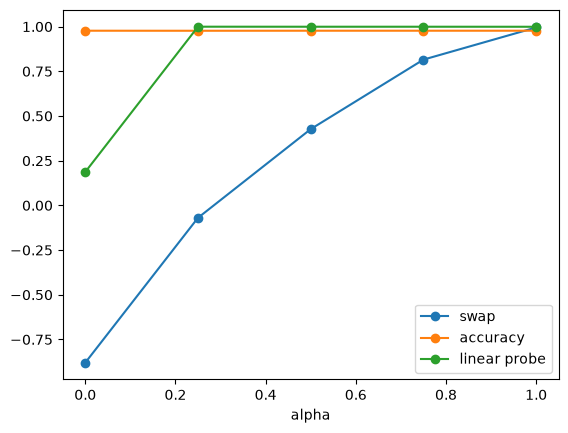

In [3]:
ALPHAS = [0.0, 0.25, 0.5, 0.75, 1.0]
p = 2.0
tr_p, tr_b = sample(3000, 0, p)
ev_p, ev_b = sample(1500, 7, p)

scores = {}
for a in ALPHAS:
    torch.manual_seed(0); net = Net(a); opt = torch.optim.Adam(net.parameters(), 3e-3)
    for _ in range(400):
        opt.zero_grad(); loss = ((net(tr_p) - tr_b) ** 2).mean(); loss.backward(); opt.step()
    net.eval()
    scores[a] = dict(acc=accuracy(net, ev_p, ev_b), lin=lin_probe(net, ev_p), swap=swap(net, ev_p, p))

for a in ALPHAS:
    s = scores[a]; print(f"alpha={a:.2f}  acc={s['acc']:.2f}  probe={s['lin']:.2f}  swap={s['swap']:.2f}")

plt.plot(ALPHAS, [scores[a]["swap"] for a in ALPHAS], "-o", label="swap")
plt.plot(ALPHAS, [scores[a]["acc"] for a in ALPHAS], "-o", label="accuracy")
plt.plot(ALPHAS, [scores[a]["lin"] for a in ALPHAS], "-o", label="linear probe")
plt.xlabel("alpha"); plt.legend(); plt.show()

## shapes: where exactly the swap happens

In [4]:
n = 4
pe, ye = sample(n, 0, 2.0)
net = Net(alpha=0.5)

print("ptt (input)      ", tuple(pe.shape))                    # (n, 1)

phys = net.physics(pe); short = net.shortcut(pe)
print("physics(ptt)     ", tuple(phys.shape))                  # (n, 1) -- Linear(1,32)->ReLU->Linear(32,1)
print("shortcut(ptt)    ", tuple(short.shape))                 # (n, 1) -- same shape, separate weights

code = net.alpha * phys + (1 - net.alpha) * short
print("code (mix)       ", tuple(code.shape))                  # (n, 1) -- elementwise blend, shape unchanged

bp_hat = net.head(code).squeeze(1)
print("head(code)->bp_hat", tuple(bp_hat.shape))                # (n,)  -- final prediction

print()
print("--- swap: replace ONLY the physics branch's input ---")
d = torch.randperm(n)
print("donor order      ", d.tolist())
phys_swapped = net.physics(pe[d])        # <- physics now sees donor ptt, shape still (n,1)
print("physics(donor)   ", tuple(phys_swapped.shape), " <-- SWAPPED IN")
print("shortcut(orig)   ", tuple(short.shape), " <-- UNCHANGED, still original ptt")

code_sw = net.alpha * phys_swapped + (1 - net.alpha) * short
print("swapped code     ", tuple(code_sw.shape))
pred_sw = net.head(code_sw).squeeze(1)
print("pred under swap  ", tuple(pred_sw.shape))

ptt (input)       (4, 1)
physics(ptt)      (4, 1)
shortcut(ptt)     (4, 1)
code (mix)        (4, 1)
head(code)->bp_hat (4,)

--- swap: replace ONLY the physics branch's input ---
donor order       [3, 1, 0, 2]
physics(donor)    (4, 1)  <-- SWAPPED IN
shortcut(orig)    (4, 1)  <-- UNCHANGED, still original ptt
swapped code      (4, 1)
pred under swap   (4,)
